<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob

## Transformasi Linier Brightness
Formula: g(x,y)=f(x,y)+b

g(x,y) adalah nilai piksel setelah transformasi, f(x,y) adalah adalah nilai piksel asli, b adalah brightness

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan : 50


/tmp/ipython-input-3857577885.py:14: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


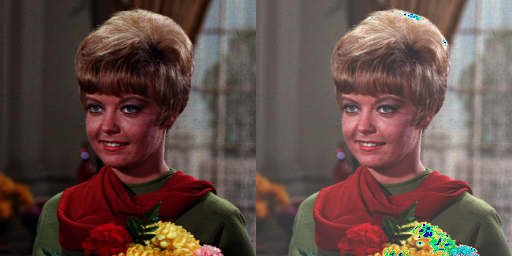

In [8]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan : '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/asset/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## Tugas Praktikum D1

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang
terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

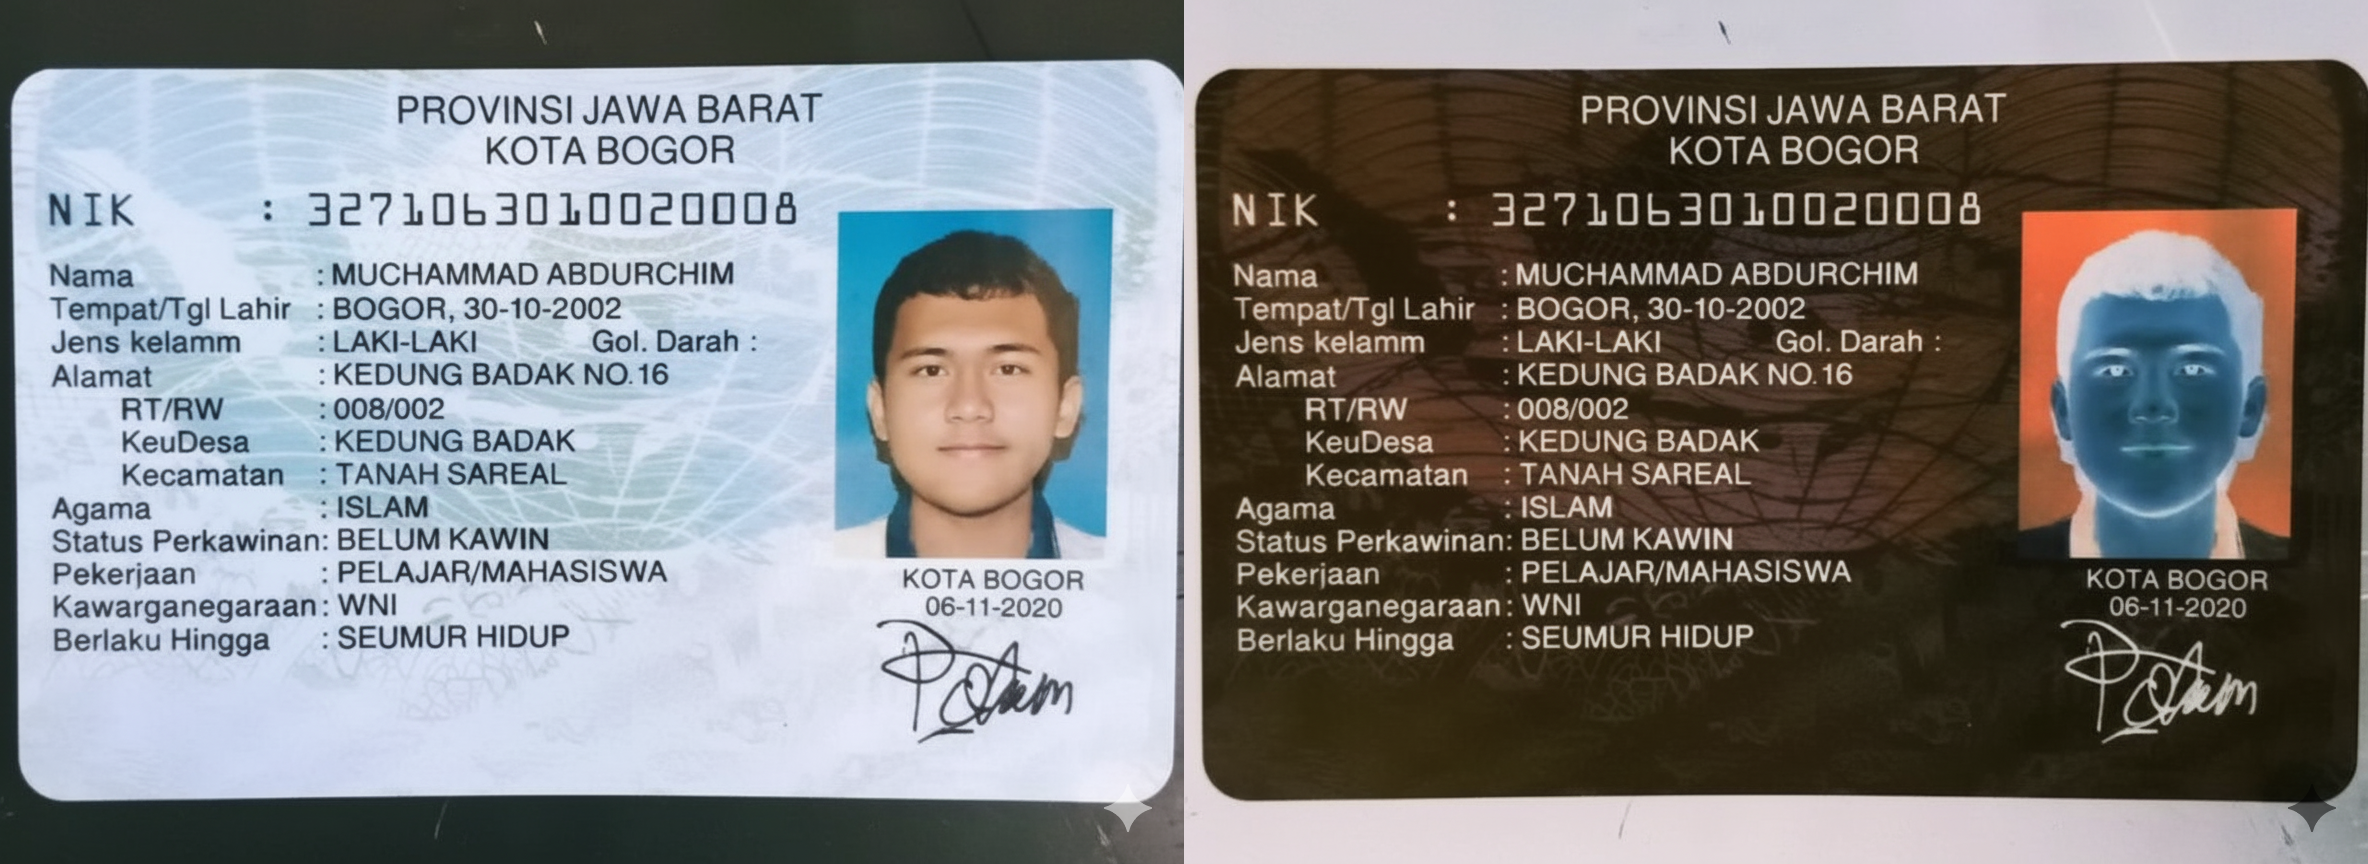

In [9]:
original = cv.imread('/content/drive/MyDrive/asset/KTP_OHIM.png')
inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      inverse_image[y,x,c] = np.clip(255 - original[y,x,c] , 0, 255)

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkqt kecerahan [-255 - 255]: 50
Masukkan kontras [1.0 - 3.0]: 2


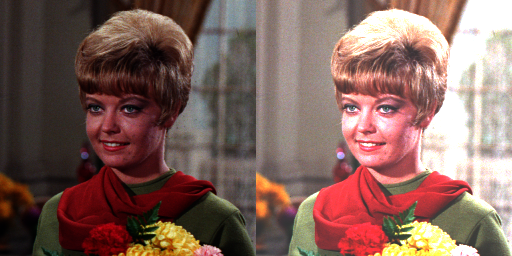

In [11]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
  brightness = int(input('Masukkan tingkat kecerahan [-255 - 255]: '))
  contrast = float(input('Masukkan kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/asset/female.tiff')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      contrast_image[y,x,c] = np.clip(contrast * original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:

Mengubah tingkat kecerahan citra dengan Tranformasi Log
-------------------------------------------------------
Masukkan nilai kecerahan: 50


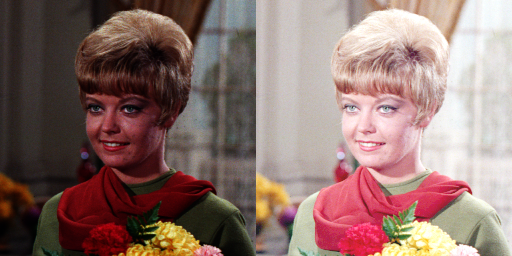

In [12]:
print('Mengubah tingkat kecerahan citra dengan Tranformasi Log')
print('-------------------------------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/asset/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(brightness * np.log1p(original[y,x,c]), 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

a. Averaging

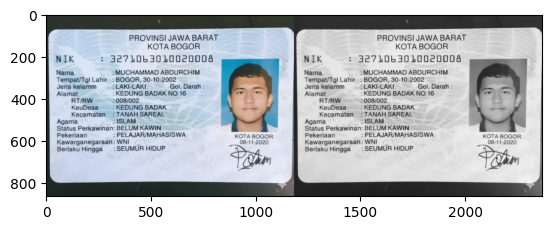

In [21]:
original = cv.imread('/content/drive/MyDrive/asset/KTP_OHIM.png')
averaging_grayscale = np.zeros((original.shape[0], original.shape[1]), original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
      averaging_grayscale[y,x] = np.clip(np.mean(original[y, x, :]), 0, 255)

grayscale_bgr = cv.cvtColor(averaging_grayscale, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, grayscale_bgr))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(final)

b. Lightness

/tmp/ipython-input-3459132219.py:5: RuntimeWarning: overflow encountered in scalar add
  lightness_grayscale[y,x] = np.clip((np.max(original[y, x, :]) + np.min(original[y, x, :]))/2, 0, 255)


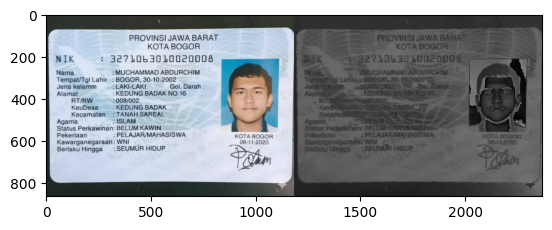

In [20]:
lightness_grayscale = np.zeros((original.shape[0], original.shape[1]), original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
      lightness_grayscale[y,x] = np.clip((np.max(original[y, x, :]) + np.min(original[y, x, :]))/2, 0, 255)

grayscale_bgr = cv.cvtColor(lightness_grayscale, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, grayscale_bgr))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(final)

c. Luminance

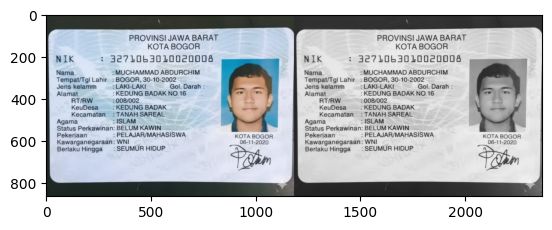

In [22]:
luminance_grayscale = np.zeros((original.shape[0], original.shape[1]), original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
      r, g, b = original[y, x]
      luminance_grayscale[y, x] = np.clip(0.21 * r + 0.72 * g + 0.07 * b, 0, 255)

grayscale_bgr = cv.cvtColor(luminance_grayscale, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, grayscale_bgr))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(final)

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna
biru menjadi grayscale seperti pada contoh berikut:

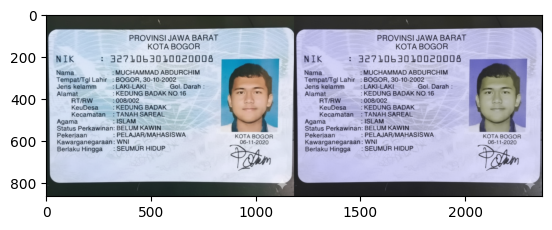

In [27]:
b, g, r = cv.split(original)

gray_val = (0.21 * r + 0.72 * g).astype(np.uint8)

allgreybutblue = cv.merge([b, gray_val, gray_val])

final_frame = cv.hconcat((original, allgreybutblue))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(final)

## Operasi Aritmatika dan Logika

1. Buat Gamma Correction sesuai dengan petunjuk berikut

Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

Gamma Correction pada citra
---------------------------
Masukkan nilai Gamma: 3


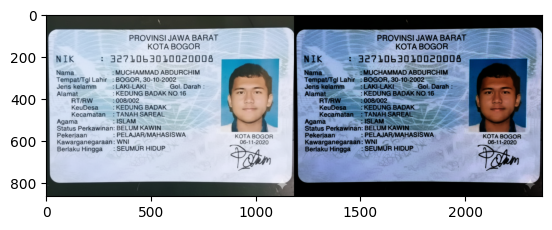

In [28]:
print('Gamma Correction pada citra')
print('---------------------------')
try:
  gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

gamma_corrected = np.array(255 * ((original / 255.0) ** gamma), dtype=np.uint8)

final_frame = cv.hconcat((original, gamma_corrected))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)

plt.imshow(final)

2. Buat Simulasi Image Depth

Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.

Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.

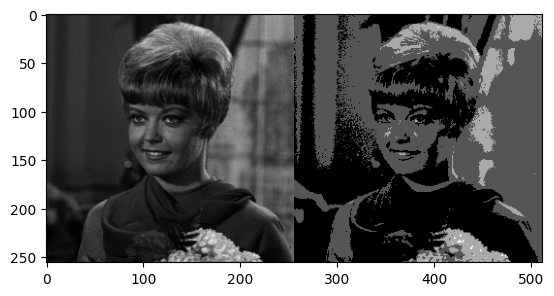

In [31]:
bit_depth=2
level = 255 / (pow(2,bit_depth)-1)
original = cv.imread('/content/drive/MyDrive/asset/female.tiff', cv.IMREAD_GRAYSCALE)

quantized = np.round(original / level) * level
quantized = np.uint8(quantized)

final_frame = cv.hconcat((original, quantized))
final = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)

plt.imshow(final)

3. Buat modul Average Denoising

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.  

Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg

Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

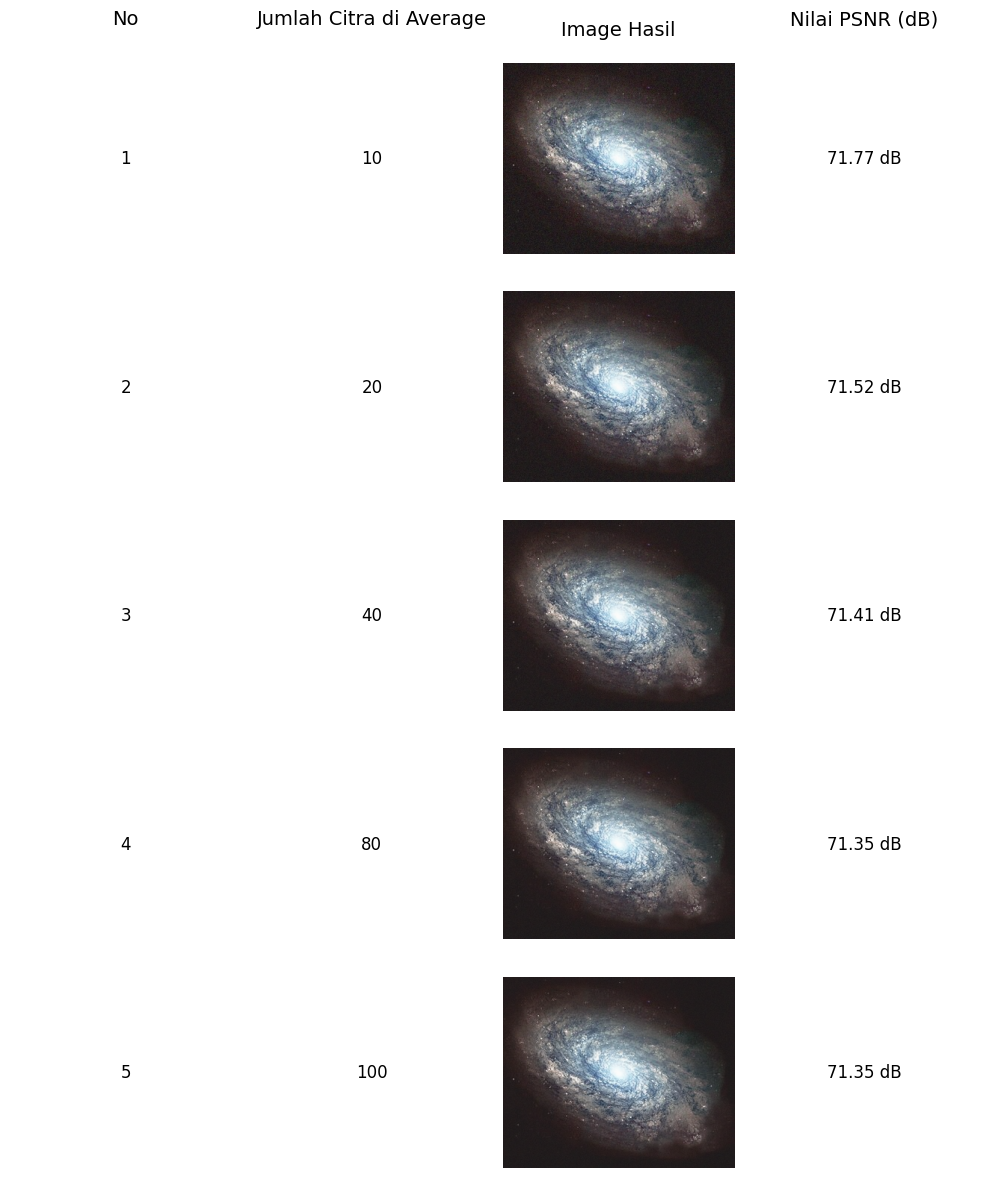

In [40]:
cv_img = []

for img in glob.glob('/content/drive/MyDrive/asset/noises/*.jpg'):
  n= cv.imread(img)
  cv_img.append(n)


def PSNR (img1, img2):
  mse = np.mean((img1/255. - img2/255.) ** 2)
  if mse == 0:
    return 100
  max_pixel = 255.0
  psnr = 20 * np.log10(max_pixel/np.sqrt(mse))
  return psnr

original = cv_img[0]

averages = [10, 20, 40, 80, 100]

fig, ax = plt.subplots(len(averages), 4, figsize=(10, 12))

for i, n in enumerate(averages):
  avg_img = np.mean(cv_img[:n], axis=0)
  avg_img = np.uint8(avg_img)

  psnr_value = PSNR(original, avg_img)

  ax[i,0].axis("off")
  ax[i,0].text(0.5, 0.5, f"{i+1}", fontsize=12, ha="center", va="center")

  ax[i,1].axis("off")
  ax[i,1].text(0.5, 0.5, f"{n}", fontsize=12, ha="center", va="center")

  ax[i,2].imshow(avg_img, cmap='gray')
  ax[i,2].axis("off")

  ax[i,3].axis("off")
  ax[i,3].text(0.5, 0.5, f"{psnr_value:.2f} dB", fontsize=12, ha="center", va="center")

for j, title in enumerate(["No", "Jumlah Citra di Average", "Image Hasil", "Nilai PSNR (dB)"]):
    ax[0,j].set_title(title, fontsize=14, pad=20)

plt.tight_layout()
plt.show()

Dari hasil PSNR yang anda catat pada tabel diatas, kesimpulan yang dapat diambil
adalah semakin banyak citra yang digunakan untuk averaging, semakin tinggi pula PSNR dan kualitas citra semakin baik

4. Image Masking

Lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini.
Tuliskan hasil analisa anda kenapa citra keluarannya seperti itu.


Operator NOT


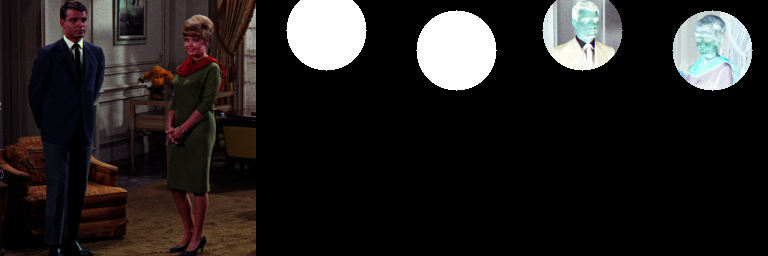

Operator OR


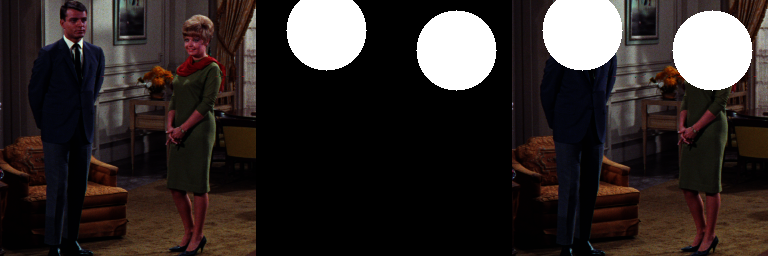

Operator AND


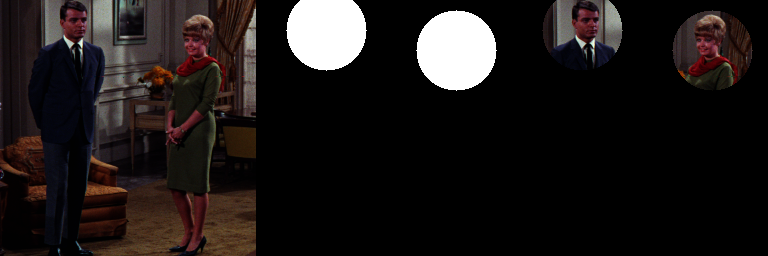

Operator NAND


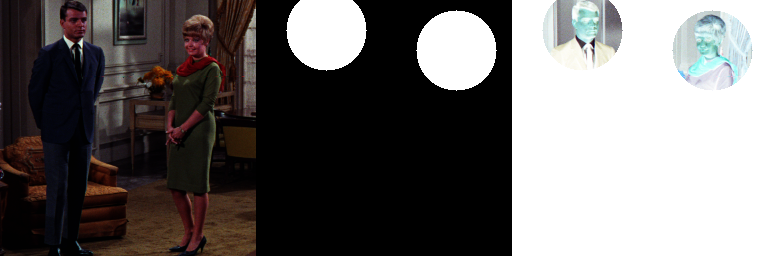

Operator XOR


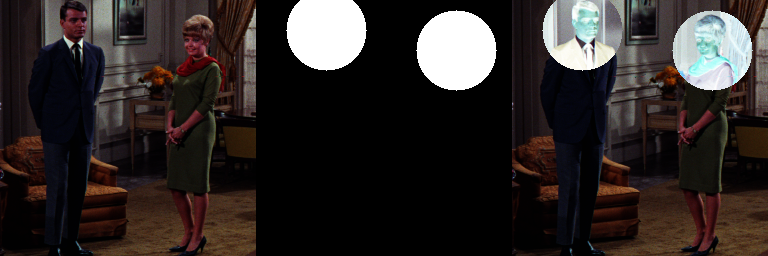

In [59]:
operators = ['NOT', 'OR', 'AND', 'NAND', 'XOR']

original = cv.imread('/content/drive/MyDrive/asset/couple.tiff')

mask = np.zeros(original.shape[:2], dtype="uint8")
cv.circle(mask, (70, 30), 40, 255, -1)
cv.circle(mask, (200, 50), 40, 255, -1)

mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

for n in operators:
    print(f'Operator {n}')
    if n == 'NOT':
        masked_img = cv.bitwise_not(original, mask=mask)
    elif n == 'OR':
        masked_img = cv.bitwise_or(original, mask_bgr)
    elif n == 'AND':
        masked_img = cv.bitwise_and(original, mask_bgr)
    elif n == 'NAND':
        and_img = cv.bitwise_and(original, mask_bgr)
        masked_img = cv.bitwise_not(and_img)
    elif n == 'XOR':
        masked_img = cv.bitwise_xor(original, mask_bgr)

    mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
    final_frame = cv.hconcat((original, mask_bgr, masked_img))
    cv2_imshow(final_frame)


Tulis hasil analisa anda:

NOT: Gambar akan ter-invers hanya di area mask

OR: Area lingkaran putih akan menyalin warna putih, sisanya akan tetap original

AND: Hanya area lingkaran putih yang muncul di original

NAND: Kebalikan dari AND, luar lingkaran putih terinvers

XOR: Area lingkaran putih menjadi invers, yang lain tetap original